# Credit Scoring - Data Preprocessing

This notebook prepares the dataset for machine learning.

The preprocessing pipeline handles missing values, suspicious values,
extreme observations and duplicate records identified during EDA.

The target variable is kept separate from feature preprocessing.

## 1. Imports & data loading

In [31]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## 2. Load raw data

In [32]:
train_df = pd.read_csv(
    'data/train.csv',
    index_col='Id'
)

test_df = pd.read_csv(
    'data/test.csv',
    index_col='Id'
)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')

Train shape: (104805, 11)
Test shape:  (45195, 10)


## 3. Separate target from features

In [33]:
TARGET = 'SeriousDlqin2yrs'

X = train_df.drop(columns=TARGET)
y = train_df[TARGET]

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')

Features: (104805, 10)
Target:   (104805,)


In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_valid: {X_valid.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_valid: {y_valid.shape}')

X_train: (83844, 10)
X_valid: (20961, 10)
y_train: (83844,)
y_valid: (20961,)


## 6. Handle duplicate observations

The EDA identified duplicated feature rows.



In [35]:
train_data = X_train.copy()
train_data[TARGET] = y_train.values

duplicate_mask = train_data.duplicated(keep=False)

print(
    f'Duplicated observations in training data: '
    f'{duplicate_mask.sum():,}'
)

Duplicated observations in training data: 407


In [36]:
duplicate_features = X_train.duplicated(
    keep=False
)

print(
    f'Duplicated feature rows: '
    f'{duplicate_features.sum():,}'
)

Duplicated feature rows: 434


In [37]:
duplicate_groups = (
    X_train.loc[duplicate_features]
    .assign(target=y_train.loc[duplicate_features])
    .groupby(list(X_train.columns))['target']
    .nunique()
)

print(
    'Duplicate feature groups with different target:',
    (duplicate_groups > 1).sum()
)

Duplicate feature groups with different target: 2


In [38]:
duplicate_features = X_train.duplicated(
    keep=False
)

print(
    f'Duplicated feature rows: '
    f'{duplicate_features.sum():,}'
)

duplicate_groups = (
    X_train.loc[duplicate_features]
    .assign(target=y_train.loc[duplicate_features])
    .groupby(list(X_train.columns))['target']
    .nunique()
)

print(
    'Duplicate feature groups with different target:',
    (duplicate_groups > 1).sum()
)

Duplicated feature rows: 434
Duplicate feature groups with different target: 2


## 7. Handle anomalous age values

The EDA identified one observation with `age = 0`.

An age of zero is not a valid borrower age in this dataset.
Therefore, this value is treated as a missing value rather than
as a valid numerical observation.

In [39]:
X_train = X_train.copy()
X_valid = X_valid.copy()

X_train.loc[X_train['age'] == 0, 'age'] = np.nan
X_valid.loc[X_valid['age'] == 0, 'age'] = np.nan

In [40]:
late_payment_features = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

## 8. Handle special delinquency value

The value `98` appears simultaneously in all three delinquency
features.

EDA showed that observations containing this special value have
a substantially higher default rate.

Therefore, the information carried by this special value should
not be discarded.

We create a binary feature indicating whether the delinquency
history contains the special value.

In [41]:
late_payment_features = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

X_train['HasUnknownDelinquencyHistory'] = (
    X_train[late_payment_features]
    .eq(98)
    .all(axis=1)
    .astype(int)
)

X_valid['HasUnknownDelinquencyHistory'] = (
    X_valid[late_payment_features]
    .eq(98)
    .all(axis=1)
    .astype(int)
)

In [42]:
print(
    X_train['HasUnknownDelinquencyHistory']
    .value_counts()
)

HasUnknownDelinquencyHistory
0    83692
1      152
Name: count, dtype: int64


In [43]:
for feature in late_payment_features:
    X_train.loc[
        X_train[feature] == 98,
        feature
    ] = np.nan

    X_valid.loc[
        X_valid[feature] == 98,
        feature
    ] = np.nan

In [44]:
print('Train:')
print(X_train[late_payment_features].isna().sum())

print('\nValidation:')
print(X_valid[late_payment_features].isna().sum())

print('\nSpecial-value indicator:')
print(
    X_train['HasUnknownDelinquencyHistory']
    .value_counts()
)

Train:
NumberOfTime30-59DaysPastDueNotWorse    152
NumberOfTime60-89DaysPastDueNotWorse    152
NumberOfTimes90DaysLate                 152
dtype: int64

Validation:
NumberOfTime30-59DaysPastDueNotWorse    29
NumberOfTime60-89DaysPastDueNotWorse    29
NumberOfTimes90DaysLate                 29
dtype: int64

Special-value indicator:
HasUnknownDelinquencyHistory
0    83692
1      152
Name: count, dtype: int64


In [45]:
for feature in late_payment_features:
    print(
        feature,
        '98 remaining:',
        (X_train[feature] == 98).sum()
    )

NumberOfTime30-59DaysPastDueNotWorse 98 remaining: 0
NumberOfTime60-89DaysPastDueNotWorse 98 remaining: 0
NumberOfTimes90DaysLate 98 remaining: 0


## 10. Missing values

After handling anomalous and special values, the dataset contains
several missing values.

Missing values will be handled using statistics calculated only
from the training data.

In [46]:
missing_train = (
    X_train.isna()
    .sum()
    .to_frame('missing_count')
)

missing_train['missing_percent'] = (
    missing_train['missing_count']
    / len(X_train)
    * 100
)

missing_train = (
    missing_train[missing_train['missing_count'] > 0]
    .sort_values('missing_percent', ascending=False)
)

missing_train

,missing_count,missing_percent
MonthlyIncome,16680,19.894
NumberOfDependents,2196,2.619
NumberOfTimes90DaysLate,152,0.181
NumberOfTime30-59DaysPastDueNotWorse,152,0.181
NumberOfTime60-89DaysPastDueNotWorse,152,0.181
age,1,0.001


In [47]:
train_medians = X_train.median(numeric_only=True)

train_medians

RevolvingUtilizationOfUnsecuredLines      0.155
age                                      52.000
NumberOfTime30-59DaysPastDueNotWorse      0.000
DebtRatio                                 0.368
MonthlyIncome                          5400.000
NumberOfOpenCreditLinesAndLoans           8.000
NumberOfTimes90DaysLate                   0.000
NumberRealEstateLoansOrLines              1.000
NumberOfTime60-89DaysPastDueNotWorse      0.000
NumberOfDependents                        0.000
HasUnknownDelinquencyHistory              0.000
dtype: float64

In [48]:
X_train = X_train.fillna(train_medians)
X_valid = X_valid.fillna(train_medians)

In [49]:
print('Missing values in X_train:')
print(X_train.isna().sum().sum())

print('\nMissing values in X_valid:')
print(X_valid.isna().sum().sum())

Missing values in X_train:
0

Missing values in X_valid:
0


In [50]:
print(X_train.shape)
print(X_valid.shape)

(83844, 11)
(20961, 11)


In [51]:
assert X_train.shape[0] == y_train.shape[0]
assert X_valid.shape[0] == y_valid.shape[0]

assert X_train.isna().sum().sum() == 0
assert X_valid.isna().sum().sum() == 0

In [52]:
X_train.dtypes

RevolvingUtilizationOfUnsecuredLines    float64
age                                     float64
NumberOfTime30-59DaysPastDueNotWorse    float64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                 float64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse    float64
NumberOfDependents                      float64
HasUnknownDelinquencyHistory              int64
dtype: object

In [53]:
print(
    'Non-numeric columns:',
    X_train.select_dtypes(exclude=np.number).columns.tolist()
)

Non-numeric columns: []


In [54]:
skewed_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome'
]

In [55]:
skewness = (
    X_train[skewed_features]
    .skew()
    .sort_values(ascending=False)
)

skewness

MonthlyIncome                          144.007
DebtRatio                               93.555
RevolvingUtilizationOfUnsecuredLines    71.443
dtype: float64

In [56]:
X_train[skewed_features].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,83844.000,5.678,214.718,0.000,0.030,0.155,0.559,29110.000
DebtRatio,83844.000,349.971,1738.287,0.000,0.176,0.368,0.870,326442.000
MonthlyIncome,83844.000,6428.416,14131.636,0.000,3900.000,5400.000,7400.000,3008750.000


In [57]:
X_train[skewed_features].skew().sort_values(ascending=False)

MonthlyIncome                          144.007
DebtRatio                               93.555
RevolvingUtilizationOfUnsecuredLines    71.443
dtype: float64

In [58]:
X_train[skewed_features].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,83844.000,5.678,214.718,0.000,0.030,0.155,0.559,29110.000
DebtRatio,83844.000,349.971,1738.287,0.000,0.176,0.368,0.870,326442.000
MonthlyIncome,83844.000,6428.416,14131.636,0.000,3900.000,5400.000,7400.000,3008750.000


## 11. Extreme value analysis

Several numerical features have highly right-skewed distributions
and extreme maximum values.


In [60]:
extreme_summary = pd.DataFrame(index=skewed_features)

extreme_summary["q99"] = X_train[skewed_features].quantile(0.99)
extreme_summary["q999"] = X_train[skewed_features].quantile(0.999)
extreme_summary["max"] = X_train[skewed_features].max()

extreme_summary["above_q99_%"] = [
    (X_train[feature] > X_train[feature].quantile(0.99)).mean() * 100
    for feature in skewed_features
]

extreme_summary

,q99,q999,max,above_q99_%
RevolvingUtilizationOfUnsecuredLines,1.092,1344.134,29110.000,1.001
DebtRatio,4984.570,10577.594,326442.000,1.001
MonthlyIncome,23452.480,72929.188,3008750.000,1.001


In [61]:
X_train[skewed_features].quantile([0.90, 0.95, 0.99, 0.999, 1.0]).T

,0.900,0.950,0.990,0.999,1.000
RevolvingUtilizationOfUnsecuredLines,0.980,1.000,1.092,1344.134,29110.000
DebtRatio,1290.700,2460.000,4984.570,10577.594,326442.000
MonthlyIncome,10800.000,13600.000,23452.480,72929.188,3008750.000


## 12. Log Transformation

Several numerical features exhibit strong right-skewed distributions
with a small number of extremely large observations.

Instead of removing these observations, a logarithmic transformation
is considered to reduce the influence of extreme values while
preserving the original information.

The transformation used is `log1p(x)`, which is defined for zero-valued
observations as well.

In [62]:
log_features = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome"
]

In [63]:
for feature in log_features:
    X_train[f"{feature}_log"] = np.log1p(X_train[feature])
    X_valid[f"{feature}_log"] = np.log1p(X_valid[feature])

In [64]:
log_columns = [
    f"{feature}_log"
    for feature in log_features
]

X_train[log_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines_log,83844.000,0.257,0.382,0.000,0.029,0.144,0.444,10.279
DebtRatio_log,83844.000,1.529,2.631,0.000,0.162,0.313,0.626,12.696
MonthlyIncome_log,83844.000,8.448,1.194,0.000,8.269,8.594,8.909,14.917


In [65]:
skewness_comparison = pd.DataFrame({
    "original": X_train[log_features].skew(),
    "log1p": X_train[log_columns].skew().values
}, index=log_features)

skewness_comparison

,original,log1p
RevolvingUtilizationOfUnsecuredLines,71.443,11.670
DebtRatio,93.555,1.744
MonthlyIncome,144.007,-4.919


### Distribution before and after log transformation

The following plots compare the original and transformed distributions
of the highly skewed numerical features.

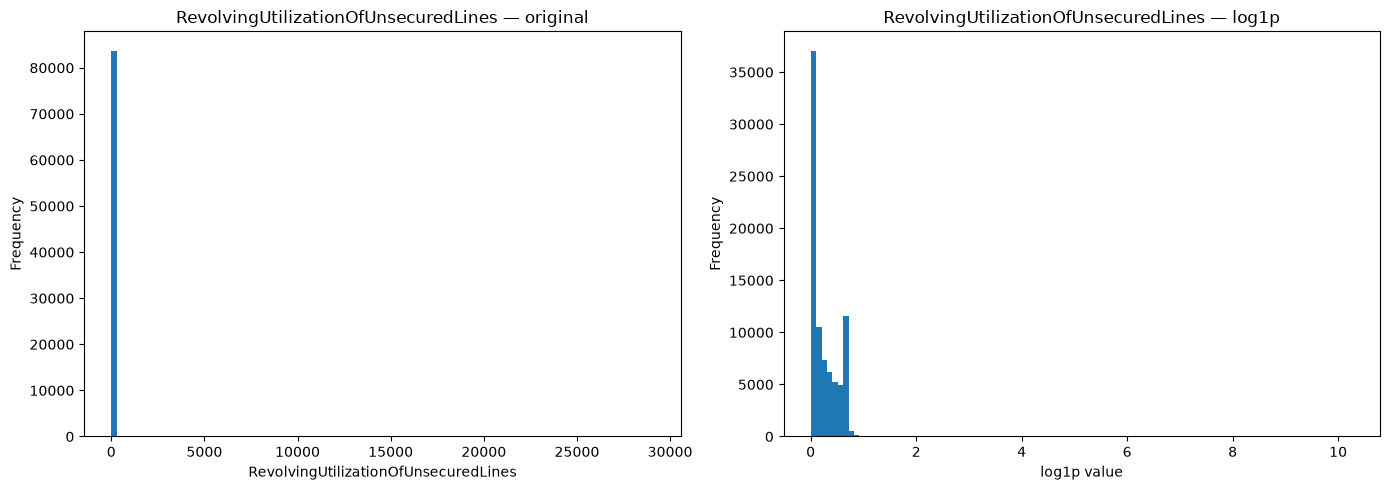

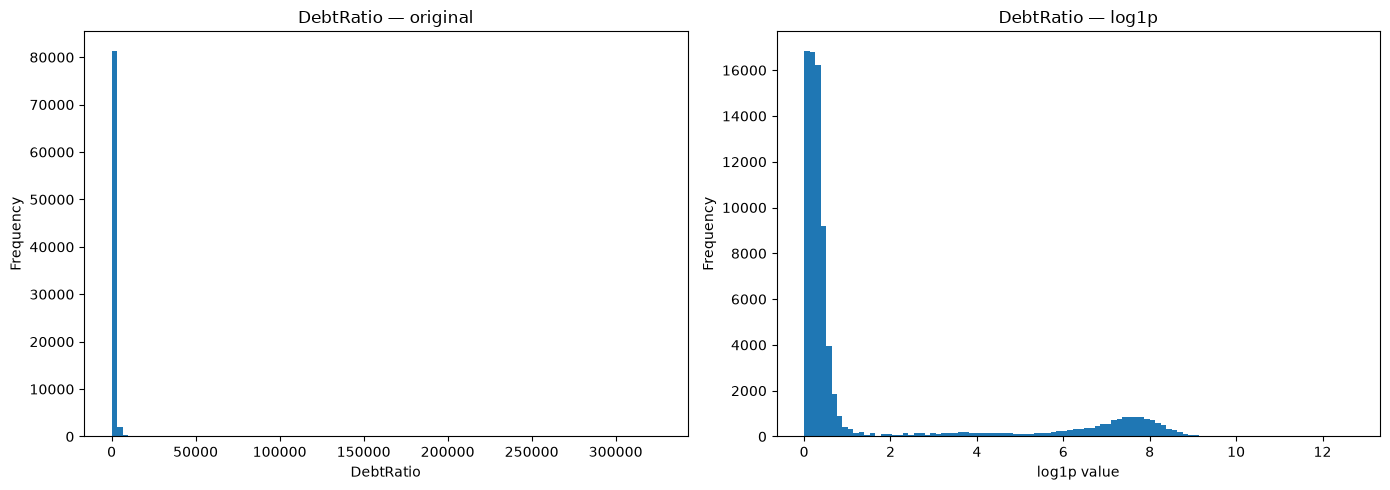

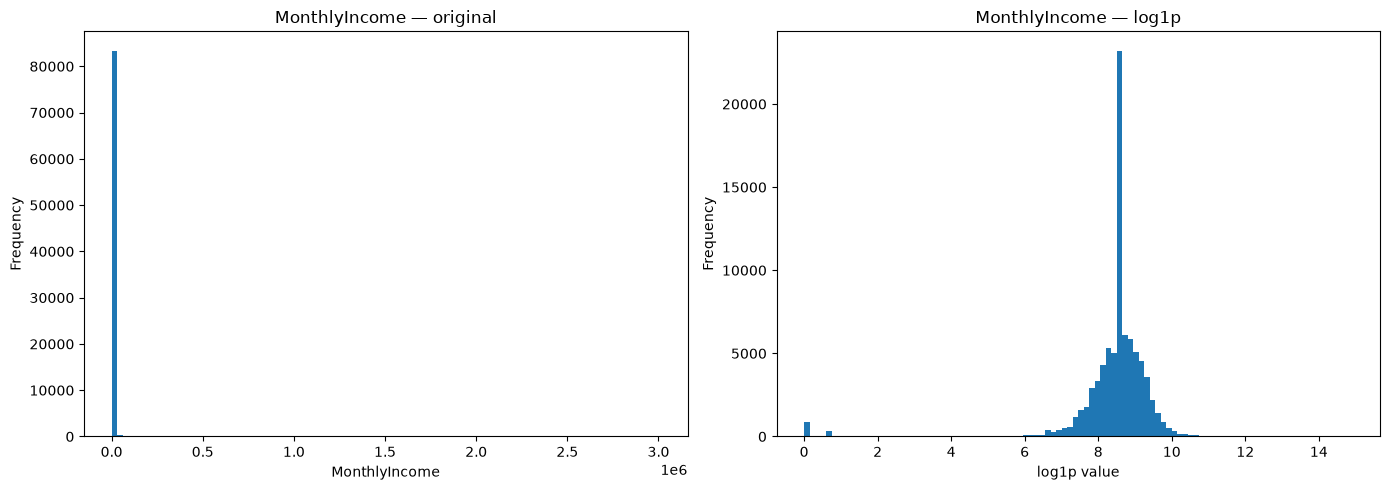

In [66]:
import matplotlib.pyplot as plt

for original, transformed in zip(log_features, log_columns):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(X_train[original], bins=100)
    axes[0].set_title(f"{original} — original")
    axes[0].set_xlabel(original)
    axes[0].set_ylabel("Frequency")

    axes[1].hist(X_train[transformed], bins=100)
    axes[1].set_title(f"{original} — log1p")
    axes[1].set_xlabel("log1p value")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()